In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import scipy.constants as spc

In [2]:
def S11_resonator(freq, fc, ke, ki, a0, a1, Poff, ed):
    numer = 1j*(freq-fc)+(ke-ki)/2
    denom = 1j*(freq-fc)-(ke+ki)/2
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(-Poff-ed*2*np.pi*freq))).conj()
    return model

In [3]:
header = "D:/K_sunada/result/CDY152/"
data = "/2023-11-25/2023-11-25T163514_2c71eaad-10_spectrum"
dd = datadict_from_hdf5(header + data +"/data")

In [4]:
s11 = dd['s11']['values']
s11_real = dd['s11']['values'].real
s11_imag = dd['s11']['values'].imag
freq = dd['frequency']['values']*1e-9

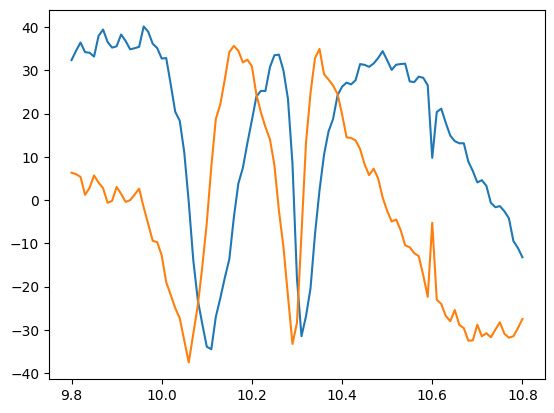

In [5]:
# plt.plot(freq, s11)
plt.plot(freq, s11_real)
plt.plot(freq, s11_imag)
plt.show()

In [6]:
par_ini = {
    'fc':10.2e9,
    'ke':0.030*1e9,
    'ki':0.0001*1e9,
    'a0':3.9356e-06,
    'a1':0.000001,
    'Poff':np.pi/2,
    'ed':0,
}

par_min = {
    'fc':0,
    'ke':0,
    'ki':0,
    'a0':- np.inf,
    'a1':- np.inf,
    'Poff':- np.pi,
    'ed':- np.inf,
}

par_max = {
    'fc':np.inf,
    'ke':np.inf,
    'ki':np.inf,
    'a0':np.inf,
    'a1':np.inf,
    'Poff':np.pi,
    'ed':np.inf,
}

par_vary = {
    'fc':True,
    'ke':True,
    'ki':True,
    'a0':True,
    'a1':True,
    'Poff':True,
    'ed':True,
}

In [7]:
model = lmfit.Model(S11_resonator)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

dpr

In [217]:
def S11_dpr_model(freq, fr, ff, kf_e, kf_i, gamma, g, a0, a1, Poff,ed):
    numer = (1j*(freq-ff)+(kf_e-kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    denom = (1j*(freq-ff)-(kf_e+kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*(freq-freq[0])))).conj()
    return model

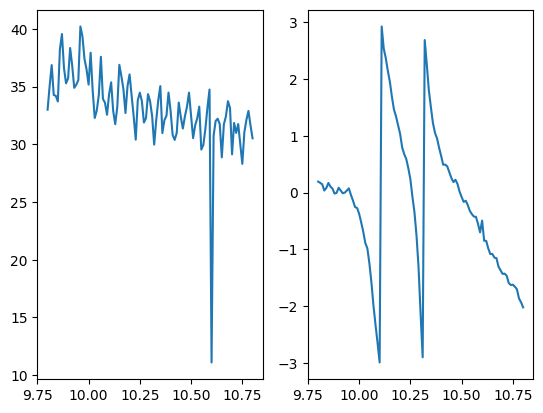

In [9]:
fig,ax = plt.subplots(1,2)
ax[0].plot(freq,np.abs(s11))
ax[1].plot(freq,np.angle(s11))

In [10]:
par_ini = {'fr': 10.225,  'ff': 10.21,    'kf_e': 230e-3,   'kf_i': 0.00001,  'g': 103e-3, 'gamma': 0.00001,
           'a0': 1.5,  'a1': 0.01,        'Poff': 0.02,   'ed': 0}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': 0,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
result = model.fit(freq=freq, data=s11, params=params, method='leastsq')

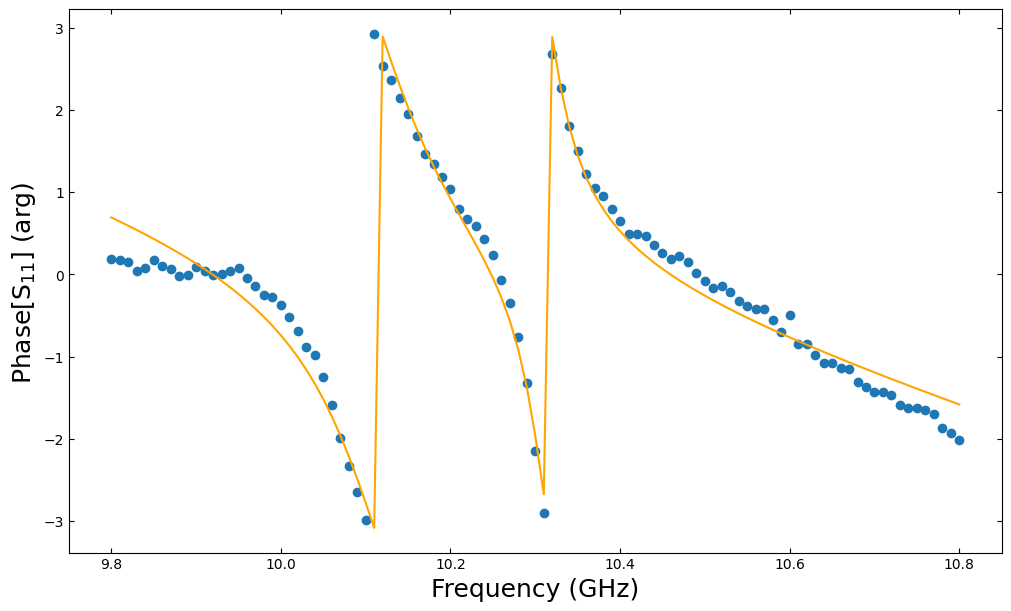

In [11]:
fig, ax = plt.subplots(figsize=(10,6),constrained_layout=True)
plt.rcParams["font.size"] = 15
ax.set_xlabel('Frequency (GHz)',fontsize=18)
ax.set_ylabel('Phase[S$_{11}$] (arg) ', fontsize=18)
# ax.tick_params(direction='in')
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)

plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

ax.plot(freq,np.angle(s11), ls='', marker='o')

ax.plot(freq,np.angle(result.best_fit), color='orange')
# ax.plot(freq,np.angle(result.init_fit), color='green', ls='--', )

# ax[1][0].plot(freq,np.abs(s11) - np.abs(result.best_fit), ls='', marker='.')
# error_phi = np.angle(s11) - np.angle(result.best_fit)
# error_phi[error_phi>np.pi] -= 2*np.pi
# error_phi[error_phi<-np.pi] += 2*np.pi
# ax[1][1].plot(freq,error_phi, ls='', marker='.')

result

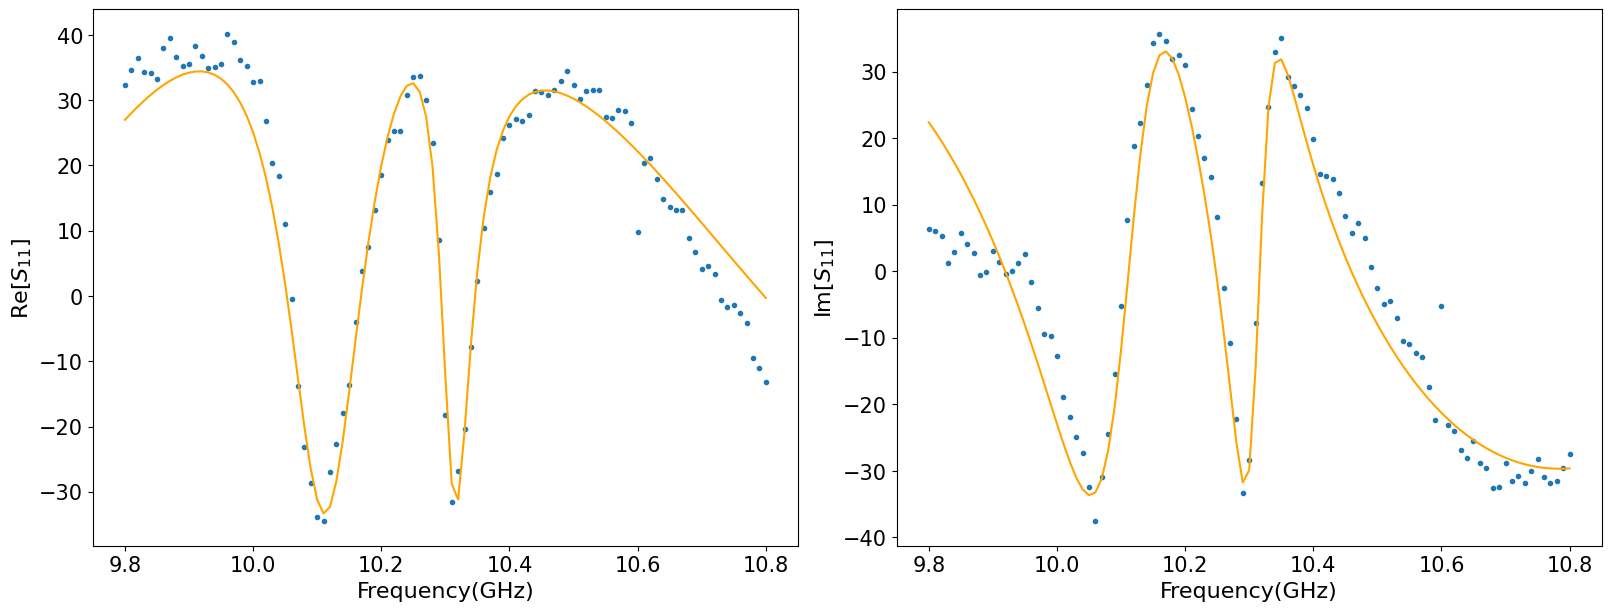

In [12]:
fig, ax = plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
ax[0].set_xlabel('Frequency(GHz)',fontsize=16)
ax[0].set_ylabel('Re[$S_{11}]$', fontsize=16)
ax[1].set_xlabel('Frequency(GHz)',fontsize=16)
ax[1].set_ylabel('Im[$S_{11}]$', fontsize=16)
# ax.tick_params(direction='in')

ax[0].plot(freq,np.real(s11), ls='', marker='.')
ax[0].plot(freq,np.real(result.best_fit), color='orange')
# ax[0].plot(freq,np.real(result.init_fit), color='green', ls='--', marker='')
ax[1].plot(freq,np.imag(s11), ls='', marker='.')
ax[1].plot(freq,np.imag(result.best_fit), color='orange')
# ax[1].plot(freq,np.imag(result.init_fit), color='green', ls='--', )
# ax[1][0].plot(freq,np.abs(s11) - np.abs(result.best_fit), ls='', marker='.')
# error_phi = np.angle(s11) - np.angle(result.best_fit)
# error_phi[error_phi>np.pi] -= 2*np.pi
# error_phi[error_phi<-np.pi] += 2*np.pi
# ax[1][1].plot(freq,error_phi, ls='', marker='.')

result

平均光子数

In [13]:
def ave_photon_number(Power, k_ex, k_in, omega_r, omega_p):
    n = (k_ex/(((k_in + k_ex)/2)**2 + (omega_r - omega_p)**2))*(Power/(spc.hbar * omega_p))
    return n

In [14]:
spc.hbar

1.0545718176461565e-34

In [15]:
k_ex = 0.19078723e9*(2*np.pi)
k_in = 0

omega_r = 10.2503210e9*2*np.pi
omega_p = 10.297e9*2*np.pi

Power =  10**((-22.4-10-2.3-50-20)/10) *1e-3#J/s
Power
# ave_photon_number(Power, k_ex, k_in, omega_r, omega_p)


3.3884415613920344e-14

In [16]:
P =  (10**((-50)/10) *1e-3  /6.626e-34 )*1e-9#GHz/s
P


1.509206157561123e+16

In [17]:
kai = (0.13e9)*2*np.pi/2
delta = (10.2503210-8.02-0.00233)*1e9*2*np.pi
g = (kai*delta)**0.5
g

2391075352.76259

In [18]:
delta**2/(4*g**2)

8.569196153846155

In [19]:
k_ex

1198751520.3334923

In [20]:
delta = omega_p - 8.02e9*2*np.pi
g = 

SyntaxError: invalid syntax (2637303568.py, line 2)

In [ ]:
Power, omega_p, omega_r, k_ex, k_in

In [ ]:
1/(10.209-10.066)

# frequency optimization

In [83]:
data = "/2023-12-12/2023-12-12T102517_4eb0a12c-26_freq_optimize"
dd = datadict_from_hdf5(header + data +"/data")
ed = 1e-9/(9.8396-9.8147)


s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_e = dd['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq))
freq = dd['frequency']['values']

eg-peak

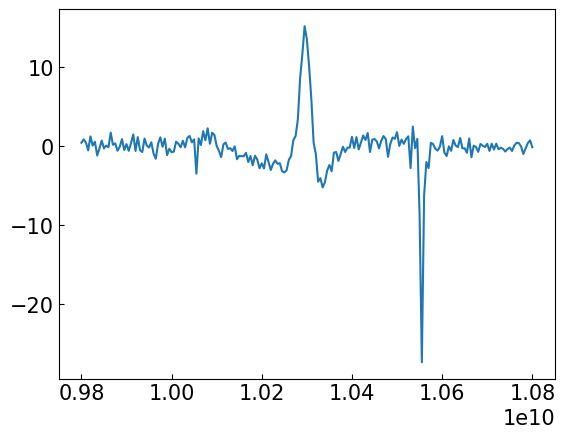

In [74]:
plt.plot(freq, s11_eg.real)
plt.show()

In [75]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [76]:
import sklearn
from sklearn.decomposition import PCA

In [77]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

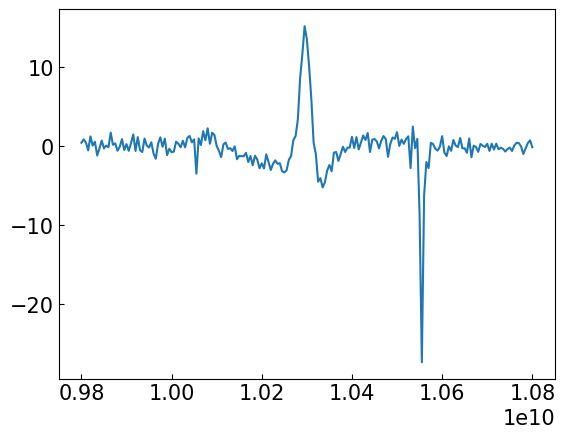

In [84]:
I = s11_eg.real
Q = s11_eg.imag
plt.plot(freq, I)
PCAge = PCA_transform(I, Q)

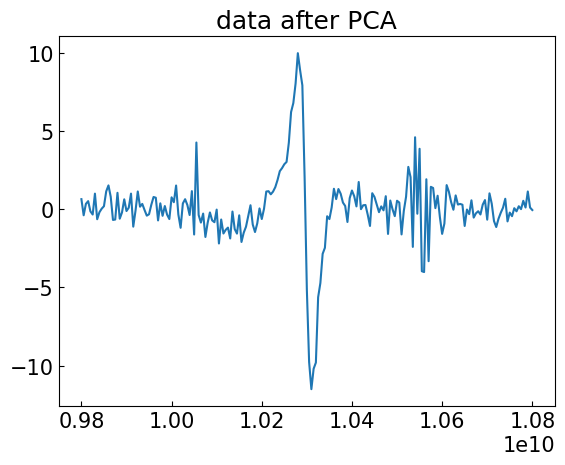

In [85]:
y = PCAge[0]
x = freq

plt.plot(x, Q)
plt.title("data after PCA")
plt.show()

In [30]:
par_ini = {
    'amp': 23,
    'const':2.5,
    'center':10.3e9,
    'k':0.008e9
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [31]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [32]:
result = model.fit(data = -Q, params = params, freq = x)
result

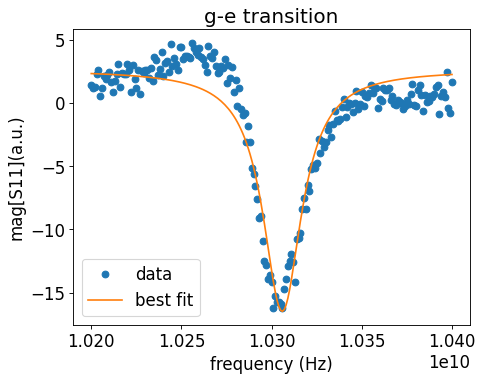

In [33]:
fig, ax = plt.subplots(dpi=80)

plt.title("g-e transition")


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)

plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

omega_g, _e fitting

In [258]:
par_ini = {'fr': 10.23e9,  'ff': 10.17e9,    'kf_e': 200e6,   'kf_i': 5e4,  'g': 103e6, 'gamma': 1000,
           'a0': 50,  'a1': 0,        'Poff': 1.5,   'ed': -0.5e-9}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': 0,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': True,    'g': True, 'gamma': True,
           'a0': True, 'a1': False,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])

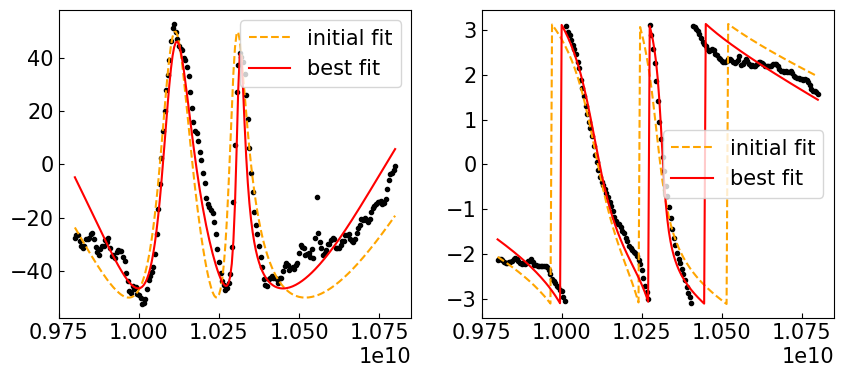

In [259]:
res = model.fit(data = s11_g, params = params, freq = x)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(x, np.real(s11_g), '.', color='k')
ax[0].plot(x, np.real(res.init_fit), '--', label='initial fit', color='orange')
ax[0].plot(x, np.real(res.best_fit), '-', label='best fit', color='red')
ax[0].legend()
ax[1].plot(x, np.angle(s11_g), '.', color='k')
ax[1].plot(x, np.angle(res.init_fit), '--', label='initial fit', color='orange')
ax[1].plot(x, np.angle(res.best_fit), '-', label='best fit', color='red')
ax[1].legend()

plt.show()
res

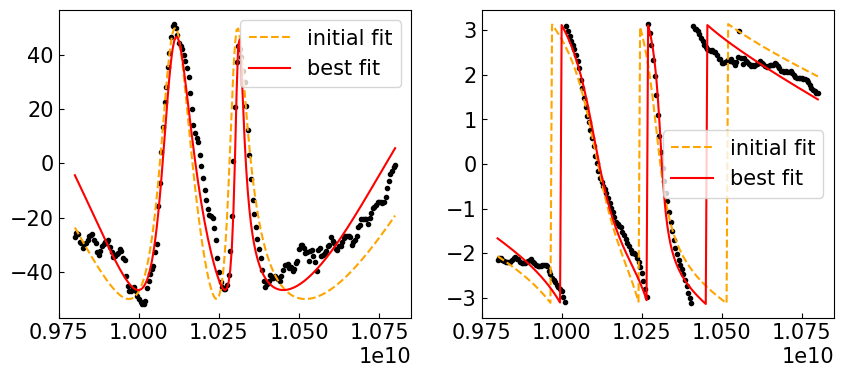

In [260]:
res = model.fit(data = s11_e, params = params, freq = x, method='nelder')

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(x, np.real(s11_e), '.', color='k')
ax[0].plot(x, np.real(res.init_fit), '--', label='initial fit', color='orange')
ax[0].plot(x, np.real(res.best_fit), '-', label='best fit', color='red')
ax[0].legend()
ax[1].plot(x, np.angle(s11_e), '.', color='k')
ax[1].plot(x, np.angle(res.init_fit), '--', label='initial fit', color='orange')
ax[1].plot(x, np.angle(res.best_fit), '-', label='best fit', color='red')
ax[1].legend()

plt.show()
res

In [253]:
f_hg = 10.268e9
f_lg = 10.147e9
f_he = 10.263e9
f_le = 10.147e9

chi_l = (f_le - f_lg)/2
chi_h = (f_he - f_hg)/2
chi = (chi_h+chi_l)/2
chi

-1250000.0